## Set up

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlite3

con = sqlite3.connect("chicago_analysis.db")
%load_ext sql
%sql sqlite:///chicago_analysis.db

#### -Top 10 community areas by crime count

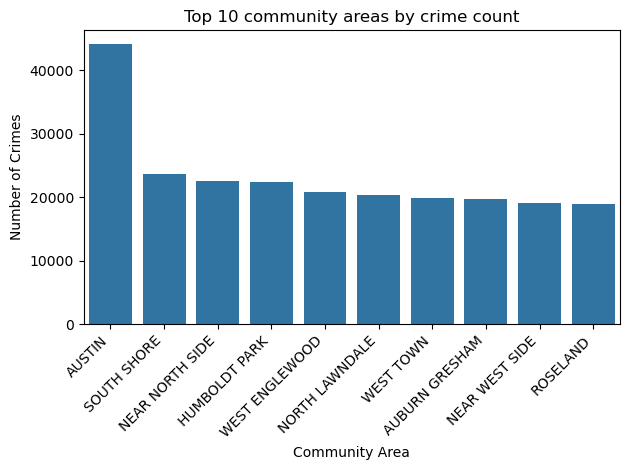

In [12]:
sql_statement = """
WITH area_names AS (
    SELECT DISTINCT community_area_number, community_area_name
    FROM SCHOOLS_DATA
)

SELECT 
    a.community_area_name AS "Community Area",
    COUNT(c.id) AS "Number of Crimes"
FROM area_names a
JOIN CRIME_DATA c
    ON a.community_area_number = CAST(c.community_area AS INTEGER)
WHERE c.community_area IS NOT NULL
GROUP BY a.community_area_number
ORDER BY COUNT(c.id) DESC
LIMIT 10
"""

df = pd.read_sql_query(sql_statement, con)


sns.barplot(
    data=df,
    x="Community Area",
    y="Number of Crimes",
)
plt.title('Top 10 community areas by crime count')
plt.xlabel('Community Area')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### -Hardship index vs Crime count

#### -Hardship index vs Avg school safety score

#### -Crime types distribution (top 10)

#### -Community areas by all 3 risk metrics